In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

DATA = Path("~/dati/walnut/Walnut1/Projections/tubeV1").expanduser()
print(sorted(p.name for p in DATA.iterdir())[:10])

['data settings XRE.txt', 'di000000.tif', 'io000000.tif', 'io000001.tif', 'scan settings.txt', 'scan_000000.tif', 'scan_000001.tif', 'scan_000002.tif', 'scan_000003.tif', 'scan_000004.tif']


In [2]:
dark = tifffile.imread(DATA / "di000000.tif")
flat0 = tifffile.imread(DATA / "io000000.tif")
flat1 = tifffile.imread(DATA / "io000001.tif")
proj = tifffile.imread(DATA / "scan_000000.tif")

for name, img in [("dark", dark), ("flat0", flat0), ("flat1", flat1), ("proj", proj)]:
    print(f"{name:6s} shape={img.shape} dtype={img.dtype} min={img.min()} max={img.max()} mean={img.mean():.1f}")

<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')


dark   shape=(768, 972) dtype=uint16 min=304 max=417 mean=342.7
flat0  shape=(768, 972) dtype=uint16 min=6340 max=14301 mean=11288.8
flat1  shape=(768, 972) dtype=uint16 min=6387 max=14394 mean=11359.4
proj   shape=(768, 972) dtype=uint16 min=3976 max=13721 mean=8345.8


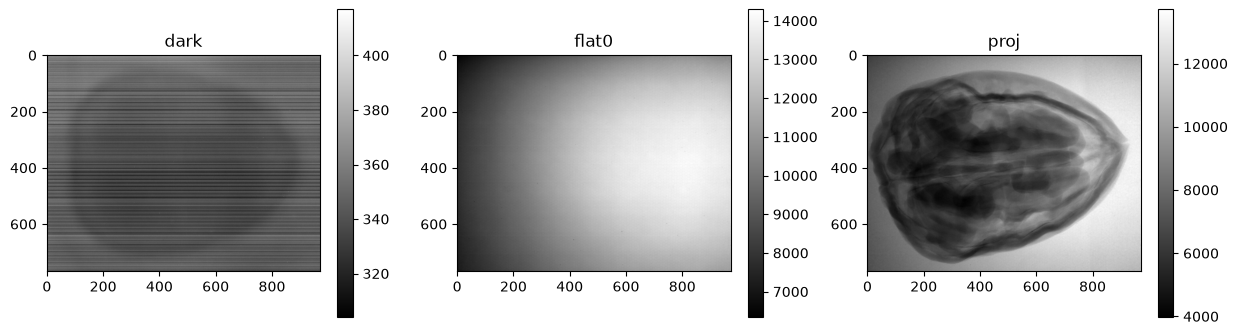

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, img) in zip(axes, [("dark", dark), ("flat0", flat0), ("proj", proj)]):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(name)
    fig.colorbar(im, ax=ax)
plt.show()

## Observations (tubeV1, Walnut1)

- **Shape**: (768, 972), transposed w.r.t. the paper (972 rows × 768 cols). Readout-column axis to be determined.
- **Range**: flat max 14394 ADU = 88% of 14-bit full scale (16383) → no saturation, ~2000 ADU headroom.
- **Dark**: 304–417 ADU, mean 343. The walnut outline is visible although the source was off → residual image from the previous exposure (detector lag). Out of scope, documented.
- **Flat**: 6340–14301 ADU, non-uniform by a factor ~2.3 → mostly beam profile (cone geometry, distance, anode heel effect), plus per-pixel gain. This is what flat-field correction removes.
- **Flat drift**: mean(flat1) − mean(flat0) = +70.6 ADU (+0.6%) over one orbit → to quantify spatially in milestone 3.


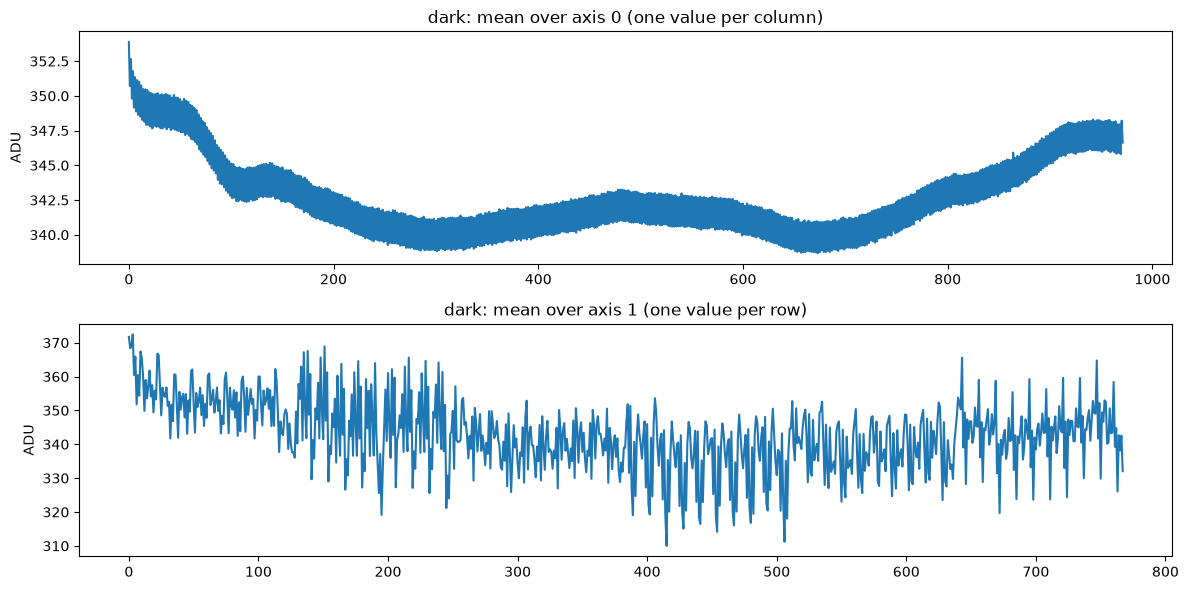

std of column means: 2.89 ADU
std of row means:    10.48 ADU
std of whole dark:   11.14 ADU


In [4]:
dark_f = dark.astype(np.float64)

col_mean = dark_f.mean(axis=0)   # one value per column (length 972)
row_mean = dark_f.mean(axis=1)   # one value per row (length 768)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(col_mean)
axes[0].set_title("dark: mean over axis 0 (one value per column)")
axes[1].plot(row_mean)
axes[1].set_title("dark: mean over axis 1 (one value per row)")
for ax in axes:
    ax.set_ylabel("ADU")
plt.tight_layout()
plt.show()

print(f"std of column means: {col_mean.std():.2f} ADU")
print(f"std of row means:    {row_mean.std():.2f} ADU")
print(f"std of whole dark:   {dark_f.std():.2f} ADU")

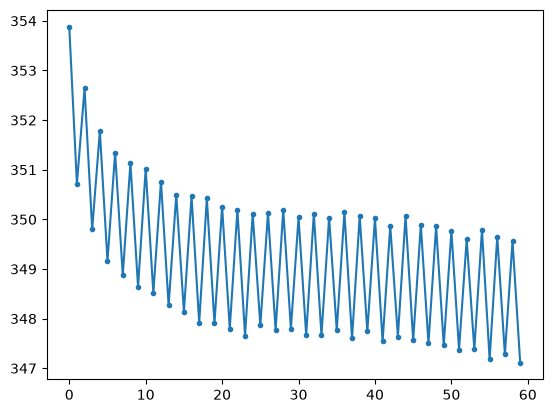

In [5]:
plt.plot(col_mean[:60], ".-")

### 1.2 Dark structure
- **Readout stripes are per row**: the dark mean of each image row jumps by tens of ADU from row to row (std 10.5 ADU) → horizontal stripes in our orientation, vertical in the paper, which displays the image transposed.
- **Row offset dominates the dark**: 88% of dark variance (110 of 124 ADU²). Residual per-pixel variability ≈ 2.4 ADU; with a single dark, pixel offset and temporal read noise cannot be separated.
- **Across columns**: slow variation of ~14 ADU, lower in the centre (consistent with the walnut residual image), plus a fast 1–2 ADU alternation between neighbours (to check: even/odd pattern).
- **Even/odd pattern along axis 1**: even indices ~2 ADU higher than odd ones, regular across the axis (hypothesis: separate readout channels). To reproduce in the simulator as a period-2 offset.
- **Edge effect**: the first ~20 columns are up to ~4 ADU higher.

min F0 after dark subtraction: 5974 ADU
ratio: mean 1.00640, std 0.00215
smoothed ratio (inner): min 1.00349, max 1.01013


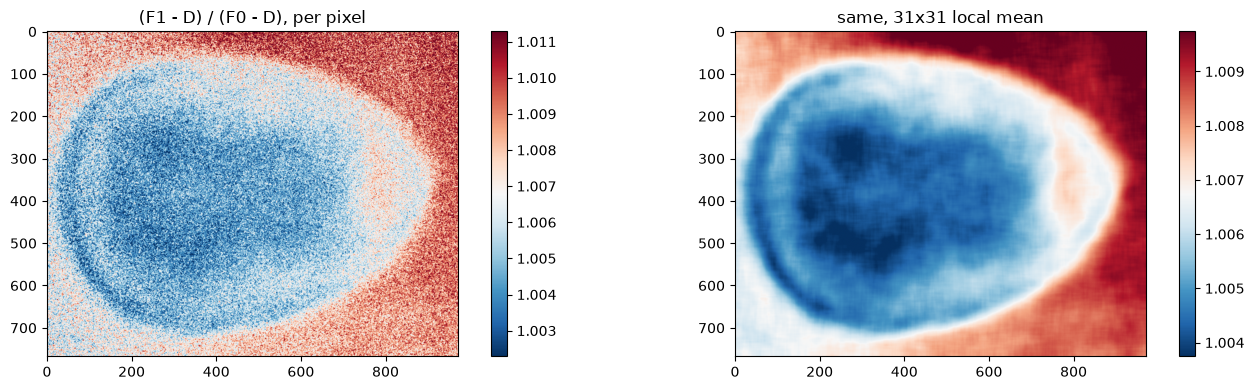

In [6]:
from scipy import ndimage

F0 = flat0.astype(np.float64) - dark_f
F1 = flat1.astype(np.float64) - dark_f
print(f"min F0 after dark subtraction: {F0.min():.0f} ADU")  # must be well above 0

ratio = F1 / F0
print(f"ratio: mean {ratio.mean():.5f}, std {ratio.std():.5f}")

ratio_smooth = ndimage.uniform_filter(ratio, size=31)
inner = ratio_smooth[31:-31, 31:-31]  # drop borders affected by the filter
print(f"smoothed ratio (inner): min {inner.min():.5f}, max {inner.max():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lo, hi = np.percentile(ratio, [1, 99])
im0 = axes[0].imshow(ratio, cmap="RdBu_r", vmin=lo, vmax=hi)
axes[0].set_title("(F1 - D) / (F0 - D), per pixel")
fig.colorbar(im0, ax=axes[0])
lo_s, hi_s = np.percentile(inner, [1, 99])
im1 = axes[1].imshow(ratio_smooth, cmap="RdBu_r", vmin=lo_s, vmax=hi_s)
axes[1].set_title("same, 31x31 local mean")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

### 1.3 Flat drift during the orbit
- **Global drift**: mean of (F1 − D)/(F0 − D) = 1.0064 → the flat increased by 0.64% between start and end of the orbit.
- **Spatial component**: not uniform. The 31×31 local mean of the ratio ranges from 1.0035 behind the walnut silhouette to 1.0101 outside it (~0.66% peak-to-peak, same order as the global part). The pattern has the shape of the walnut.
- **Interpretation**: an object-shaped change can only come from detector memory of the scan. Pixels outside the walnut received more exposure and show more residual signal (lag), the same effect visible in the dark.
- **Consequence for milestone 3**: no single flat represents the whole scan. Flat-field correction carries an object-dependent residual error of order 0.5%. Lag stays out of scope: not corrected, but quantified as a limitation.

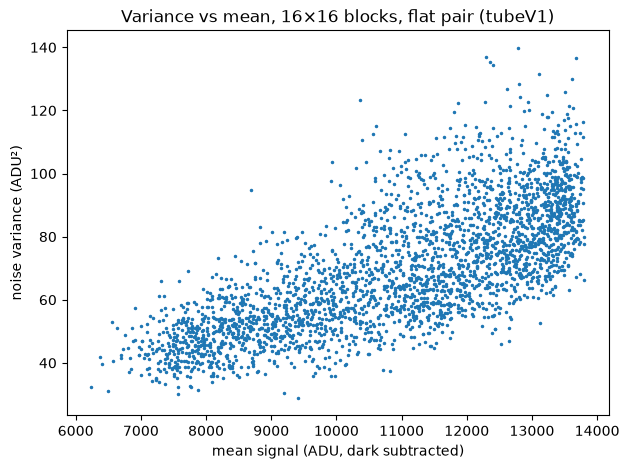

slope K ≈ 0.0073 ADU per quantum, intercept ≈ -10.9 ADU²


In [7]:
B = 16  # block size in pixels
n_rows, n_cols = F0.shape  # F0, F1: dark-subtracted float flats from step 3

means, variances = [], []
for r in range(0, n_rows - B + 1, B):
    for c in range(0, n_cols - B + 1, B):
        f0 = F0[r:r+B, c:c+B]
        f1 = F1[r:r+B, c:c+B]
        means.append(0.5 * (f0.mean() + f1.mean()))
        variances.append(np.var(f1 - f0) / 2)

means = np.array(means)
variances = np.array(variances)

plt.figure(figsize=(7, 5))
plt.plot(means, variances, ".", markersize=3)
plt.xlabel("mean signal (ADU, dark subtracted)")
plt.ylabel("noise variance (ADU²)")
plt.title("Variance vs mean, 16×16 blocks, flat pair (tubeV1)")
plt.show()

slope, intercept = np.polyfit(means, variances, 1)
print(f"slope K ≈ {slope:.4f} ADU per quantum, intercept ≈ {intercept:.1f} ADU²")

### 1.4 Noise: variance vs mean (flat pair)
- **Method**: var(F1 − F0)/2 in 16×16 blocks vs block mean of dark-subtracted flats. The difference removes everything fixed (beam profile, pixel gain, dark), leaving only noise.
- **Result**: variance grows with signal, from ~45 ADU² at 7000 ADU to ~90 ADU² at 13500 ADU → signal-dependent noise, consistent with counting statistics. Linear fit: slope 0.0073 ADU per quantum (effective), intercept −10.9 ADU².
- **Caveats**: the negative intercept is unphysical (data cover only 6000–14000 ADU, so extrapolation to zero is unreliable). Scatter is larger than expected from 256 pixels per block (~9%), still unexplained. The slope is an effective gain, not ADU per X-ray photon: scintillator blur and 2×2 binning reduce the measured variance. To be quantified with the simulator.

## 2. Checks for the simulator model

Checks run while defining the simulator (Milestone 2). Each one answers a question that decides where a feature of the real data goes in the simulated signal chain.

### 2.1 Flat structure: beam profile or pixel gain?

**Question.** The dark-subtracted flat ranges from ~6000 to ~14000 ADU. In the simulator this non-uniformity can enter before the quantum noise (beam profile) or after it (pixel gain). Which one dominates?

**Method.** Compare the slow variation along a row with the pixel-to-pixel variation in a small crop, where the slow variation is nearly constant.

**Result.** Along the central row the signal rises smoothly from ~7500 to ~13900 ADU, maximum near column 800 (not at the centre). In the crop, pixel-to-pixel differences are tens to hundreds of ADU, with a fixed hexagonal pattern (cells of ~10 pixels). The slow part is assigned to the beam, the fast part to the gain map.

<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')


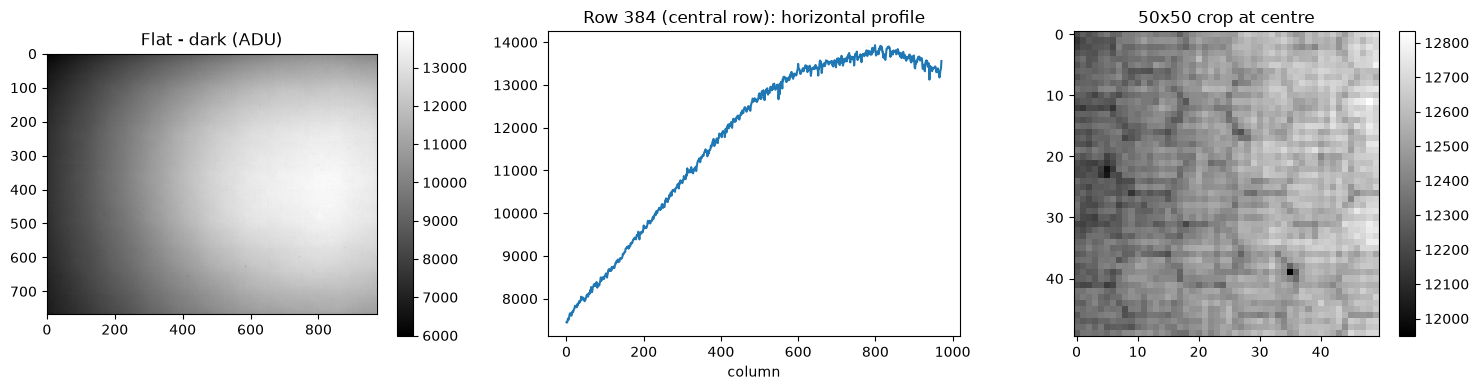

In [13]:
dark = tifffile.imread(DATA / "di000000.tif").astype(np.float64)
f0 = tifffile.imread(DATA / "io000000.tif").astype(np.float64)
f1 = tifffile.imread(DATA / "io000001.tif").astype(np.float64)
flat = f0 - dark  # dark-subtracted flat, acquired before the scan

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im = ax[0].imshow(flat, cmap="gray")
fig.colorbar(im, ax=ax[0])
ax[0].set_title("Flat - dark (ADU)")
ax[1].plot(flat[384, :])
ax[1].set_xlabel("column")
ax[1].set_title("Row 384 (central row): horizontal profile")
im = ax[2].imshow(flat[350:400, 450:500], cmap="gray")
fig.colorbar(im, ax=ax[2])
ax[2].set_title("50x50 crop at centre")
plt.tight_layout()
plt.show()

### 2.2 Dark decomposition: what is the per-pixel spread?

**Question.** How much of the dark variation is explained by row and column structure, and what is left?

**Method.** Remove the mean of each row, then the mean of each column, and print the standard deviation after each step.

**Result.** Std 11.1 ADU → 3.8 ADU after removing row offsets → 2.5 ADU after removing column offsets. The remaining 2.5 ADU is per-pixel offset (fixed) plus read noise (temporal). Variances add: 2.5² = σ_offset² + σ_read². A single dark cannot separate the two terms; the difference of two darks cancels the fixed one.

dark: mean 342.7 ADU, std 11.1 ADU
after removing row offsets:    std 3.8 ADU
after removing column offsets: std 2.5 ADU


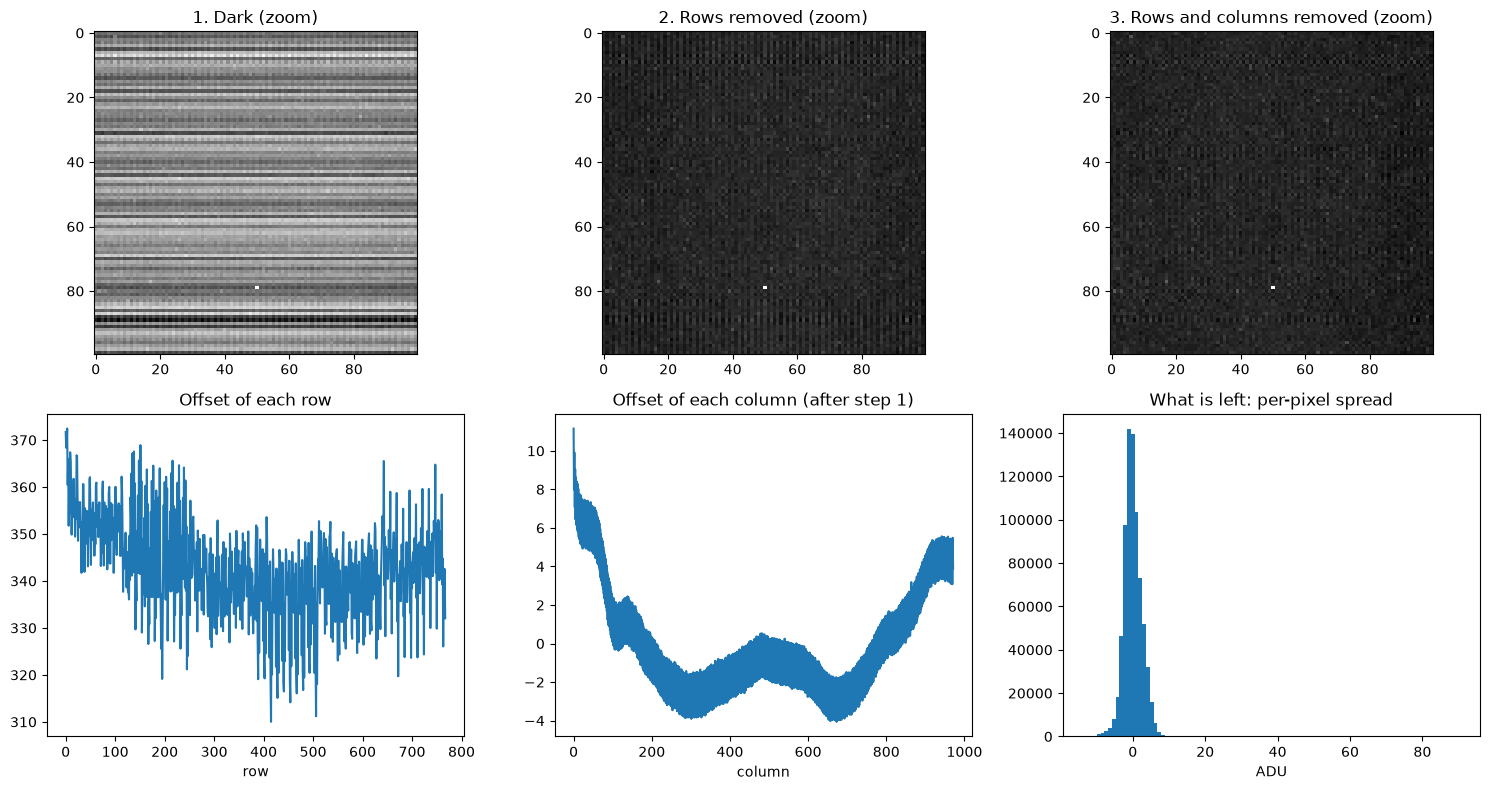

In [14]:
print(f"dark: mean {dark.mean():.1f} ADU, std {dark.std():.1f} ADU")

# Step 1: remove one offset per row (the stripes)
row_offset = dark.mean(axis=1)            # 768 values, one per row
step1 = dark - row_offset[:, np.newaxis]  # subtract each row's mean from that row
print(f"after removing row offsets:    std {step1.std():.1f} ADU")

# Step 2: remove one offset per column (even/odd, edge, slow variation)
col_offset = step1.mean(axis=0)           # 972 values, one per column
step2 = step1 - col_offset[np.newaxis, :]
print(f"after removing column offsets: std {step2.std():.1f} ADU")

zoom = (slice(300, 400), slice(400, 500))  # 100x100 window near the centre

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0, 0].imshow(dark[zoom], cmap="gray")
ax[0, 0].set_title("1. Dark (zoom)")
ax[0, 1].imshow(step1[zoom], cmap="gray")
ax[0, 1].set_title("2. Rows removed (zoom)")
ax[0, 2].imshow(step2[zoom], cmap="gray")
ax[0, 2].set_title("3. Rows and columns removed (zoom)")
ax[1, 0].plot(row_offset)
ax[1, 0].set_title("Offset of each row")
ax[1, 0].set_xlabel("row")
ax[1, 1].plot(col_offset)
ax[1, 1].set_title("Offset of each column (after step 1)")
ax[1, 1].set_xlabel("column")
ax[1, 2].hist(step2.ravel(), bins=100)
ax[1, 2].set_title("What is left: per-pixel spread")
ax[1, 2].set_xlabel("ADU")
plt.tight_layout()
plt.show()

### 2.3 Are the row offsets fixed or do they change from frame to frame?

**Question.** If the row stripes are fixed, dark subtraction removes them and they belong to the offset map. If they change between frames, they are noise.

**Method.** The two flats were acquired at different times. Their difference F1 − F0 cancels everything fixed (offset, fixed stripes, beam, gain). Stripes that changed between frames would survive in it. Compare the row-to-row jumps of the row means in the dark and in F1 − F0, and with the jumps expected from pixel noise alone.

**Result.** Row-to-row jumps: std 12.3 ADU in the dark, 0.55 ADU in F1 − F0, ~0.4 ADU expected from pixel noise alone (approximate: the estimate uses neighbouring pixels, which are correlated by the scintillator blur, so it is slightly low). The stripes are fixed.

The slow curve of the row means of F1 − F0 (60–90 ADU) is the flat drift (~0.64% of the signal). Its valley corresponds to the rows where the walnut is widest: there, more columns lie behind the walnut, where the drift is smaller (residual image).

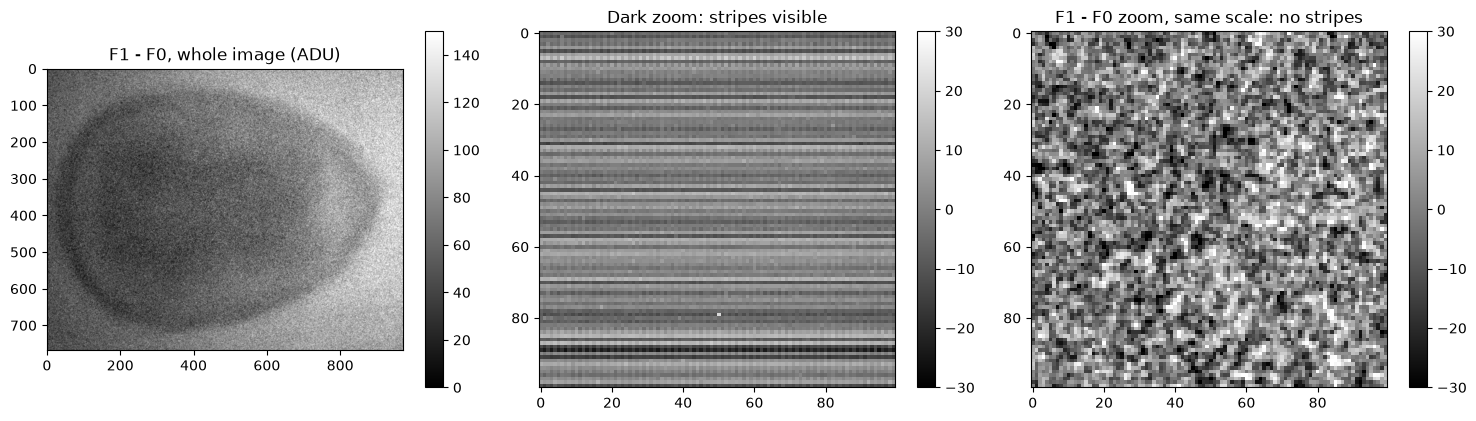

jumps in the dark:  std 12.34 ADU
jumps in F1 - F0:   std 0.55 ADU
expected from pixel noise alone: 0.38 ADU


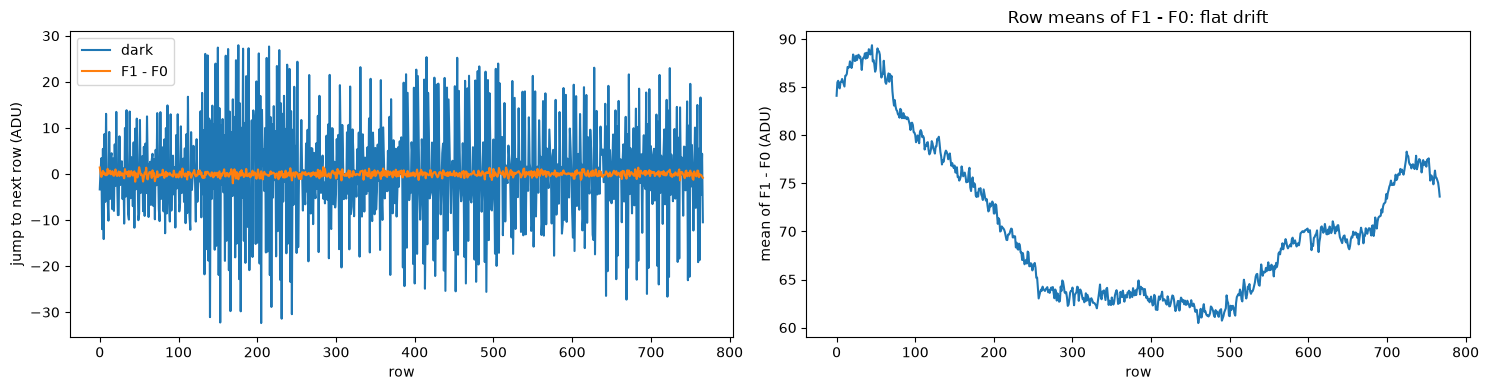

In [15]:
flat_diff = f1 - f0  # fixed things cancel: offset, fixed stripes, beam, gain

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im = ax[0].imshow(flat_diff, cmap="gray", vmin=0, vmax=150)
fig.colorbar(im, ax=ax[0])
ax[0].set_title("F1 - F0, whole image (ADU)")
im = ax[1].imshow(dark[zoom] - dark[zoom].mean(), cmap="gray", vmin=-30, vmax=30)
fig.colorbar(im, ax=ax[1])
ax[1].set_title("Dark zoom: stripes visible")
im = ax[2].imshow(flat_diff[zoom] - flat_diff[zoom].mean(), cmap="gray", vmin=-30, vmax=30)
fig.colorbar(im, ax=ax[2])
ax[2].set_title("F1 - F0 zoom, same scale: no stripes")
plt.tight_layout()
plt.show()

# Row-to-row jumps: how much each row's mean differs from the next row's mean
dark_jumps = np.diff(dark.mean(axis=1))
diff_row_means = flat_diff.mean(axis=1)
diff_jumps = np.diff(diff_row_means)

# Jumps expected from pixel noise alone (approximate)
pixel_noise = np.diff(flat_diff, axis=1).std() / np.sqrt(2)
expected = pixel_noise * np.sqrt(2) / np.sqrt(flat_diff.shape[1])

print(f"jumps in the dark:  std {dark_jumps.std():.2f} ADU")
print(f"jumps in F1 - F0:   std {diff_jumps.std():.2f} ADU")
print(f"expected from pixel noise alone: {expected:.2f} ADU")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(dark_jumps, label="dark")
ax[0].plot(diff_jumps, label="F1 - F0")
ax[0].set_xlabel("row")
ax[0].set_ylabel("jump to next row (ADU)")
ax[0].legend()
ax[1].plot(diff_row_means)
ax[1].set_xlabel("row")
ax[1].set_ylabel("mean of F1 - F0 (ADU)")
ax[1].set_title("Row means of F1 - F0: flat drift")
plt.tight_layout()
plt.show()